## **IMPORT**

In [42]:
#%pip install -q streamlit

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import xgboost as xgb
import joblib
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE,RandomOverSampler
from sklearn.model_selection import train_test_split,cross_validate,StratifiedKFold,KFold,StratifiedGroupKFold,GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score
                             )
pd.set_option('display.float_format', lambda x: '%.4f' % x)

## **LOAD DATASET**

In [81]:
df = pd.read_csv("loan.csv")
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0000,71.0000,360.0000,1.0000,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0000,40.0000,180.0000,1.0000,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0000,253.0000,360.0000,1.0000,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0000,187.0000,360.0000,1.0000,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0000,133.0000,360.0000,0.0000,Semiurban,N


## **DATA OVERVIEW**

In [45]:
df.shape

(614, 13)

In [46]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [47]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [49]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [50]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.0000,614.0000,592.0000,600.0000,564.0000
mean,5403.4593,1621.2458,146.4122,342.0000,0.8422
std,6109.0417,2926.2484,85.5873,65.1204,0.3649
min,150.0000,0.0000,9.0000,12.0000,0.0000
25%,2877.5000,0.0000,100.0000,360.0000,1.0000
50%,3812.5000,1188.5000,128.0000,360.0000,1.0000
75%,5795.0000,2297.2500,168.0000,360.0000,1.0000
max,81000.0000,41667.0000,700.0000,480.0000,1.0000


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df = df.drop(columns = "Loan_ID")

In [53]:
#df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

## **DATA PREPROCESSING**

## **TRAIN, TEST, SPLIT**

In [54]:
X = df.drop(columns="Loan_Status")
y = df["Loan_Status"]

In [55]:
y.value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [56]:
y.value_counts(normalize=True)

Loan_Status
Y   0.6873
N   0.3127
Name: proportion, dtype: float64

In [57]:
def check_ratio(y):
    d = {
        "count" : y.value_counts(),
        "percent" : round(y.value_counts(normalize=True), 3)
    }
    y_ratio = pd.DataFrame(d)
    return y_ratio

In [58]:
check_ratio(y)

,count,percent
Loan_Status,,
Y,422,0.6870
N,192,0.3130


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
d = {
    "y_percent" : round(y.value_counts(normalize=True), 4),
    "y_train_percent" : round(y_train.value_counts(normalize=True), 4),
    "y_test_percent" : round(y_test.value_counts(normalize=True), 4)
}
y_ratio = pd.DataFrame(d)
y_ratio 

,y_percent,y_train_percent,y_test_percent
Loan_Status,,,
Y,0.6873,0.6864,0.6911
N,0.3127,0.3136,0.3089


## **HANDLING MISSING VALUES**

In [61]:
def check_uniques(df):
    for i in df.columns:
     if df[i].nunique() <= 10:
        unique_columns = df[i].unique()
        print(f"{i} --> {unique_columns}")
        print("*"*50)

check_uniques(df)

Gender --> <ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
**************************************************
Married --> <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
**************************************************
Dependents --> <ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
**************************************************
Education --> <ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
**************************************************
Self_Employed --> <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
**************************************************
Loan_Amount_Term --> [360. 120. 240.  nan 180.  60. 300. 480.  36.  84.  12.]
**************************************************
Credit_History --> [ 1.  0. nan]
**************************************************
Property_Area --> <ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str
************************************************

In [62]:
def missing_report(df):
    missing_summary = pd.DataFrame(
        {
            "missing_count": df.isna().sum().sort_values(ascending=False),
            "missing_percent": (df.isna().mean() * 100).sort_values(ascending=False)
        }
    )
    return missing_summary
missing_report(df)

,missing_count,missing_percent
Credit_History,50,8.1433
Self_Employed,32,5.2117
LoanAmount,22,3.5831
Dependents,15,2.4430
Loan_Amount_Term,14,2.2801
Gender,13,2.1173
Married,3,0.4886
Education,0,0.0000
CoapplicantIncome,0,0.0000
ApplicantIncome,0,0.0000


In [63]:
numerical = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
categorical = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Credit_History", "Dependents"]

In [64]:
for i in numerical:
    X_train_avg = X_train[i].mean()
    X_train[i] = X_train[i].fillna(X_train_avg)
    X_test[i] = X_test[i].fillna(X_train_avg)
missing_report(X_train)

,missing_count,missing_percent
Credit_History,43,8.7576
Self_Employed,27,5.4990
Gender,11,2.2403
Dependents,8,1.6293
Married,3,0.6110
ApplicantIncome,0,0.0000
Education,0,0.0000
CoapplicantIncome,0,0.0000
LoanAmount,0,0.0000
Loan_Amount_Term,0,0.0000


In [65]:
for i in categorical:
    X_train_mode = X_train[i].mode()[0]
    X_train[i] = X_train[i].fillna(X_train_mode)
    X_test[i] = X_test[i].fillna(X_train_mode)
missing_report(X_train)

,missing_count,missing_percent
Gender,0,0.0000
Married,0,0.0000
Dependents,0,0.0000
Education,0,0.0000
Self_Employed,0,0.0000
ApplicantIncome,0,0.0000
CoapplicantIncome,0,0.0000
LoanAmount,0,0.0000
Loan_Amount_Term,0,0.0000
Credit_History,0,0.0000


In [66]:
y.isna().sum()

np.int64(0)

## **ENCODING**

In [67]:
ord_bin_cat = ["Gender", "Married", "Education", "Self_Employed", "Credit_History"]
nominal_cat = ["Dependents", "Property_Area"]

In [68]:
3
ord_bin_cat = ["Gender", "Married", "Education", "Self_Employed","Credit_History"]
label_enc_classes = {}

for i in ord_bin_cat:
    le = LabelEncoder()
    le.fit(X_train[i])
    X_train[i] = le.transform(X_train[i])
    X_test[i] = le.transform(X_test[i])
    
    label_enc_classes[i] = le
    
label_enc_classes

{'Gender': LabelEncoder(),
 'Married': LabelEncoder(),
 'Education': LabelEncoder(),
 'Self_Employed': LabelEncoder(),
 'Credit_History': LabelEncoder()}

In [69]:
label_enc_classes = {}
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)    
label_enc_classes = le
    
label_enc_classes

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](2,)","['N','Y']"


In [70]:
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)
ohe.fit(X_train[nominal_cat])
ohe_encoded_cols = ohe.get_feature_names_out()
print(ohe_encoded_cols)

train_encoded = ohe.transform(X_train[nominal_cat])
test_encoded = ohe.transform(X_test[nominal_cat])

train_df = pd.DataFrame(train_encoded, columns=ohe_encoded_cols, index=X_train.index)
test_df = pd.DataFrame(test_encoded, columns=ohe_encoded_cols, index=X_test.index)

X_train = X_train.drop(columns=nominal_cat)
X_test = X_test.drop(columns=nominal_cat)

X_train = pd.concat([X_train, train_df], axis=1)
X_test = pd.concat([X_test, test_df], axis=1)

X_train.head()

['Dependents_1' 'Dependents_2' 'Dependents_3+' 'Property_Area_Semiurban'
 'Property_Area_Urban']


,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
154,1,0,0,0,3254,0.0000,50.0000,360.0000,1,0.0000,0.0000,0.0000,0.0000,1.0000
239,1,1,0,0,3315,0.0000,96.0000,360.0000,1,1.0000,0.0000,0.0000,1.0000,0.0000
448,1,1,0,0,3340,1710.0000,150.0000,360.0000,0,0.0000,1.0000,0.0000,0.0000,0.0000
471,1,1,1,0,2653,1500.0000,113.0000,180.0000,0,1.0000,0.0000,0.0000,0.0000,0.0000
273,1,1,0,0,2620,2223.0000,150.0000,360.0000,1,0.0000,0.0000,0.0000,1.0000,0.0000


## **HANDLE IMBALANCE**

In [71]:
smote = SMOTE(random_state=42)
X_train_so, y_train_so = smote.fit_resample(X_train,y_train)

## **PIPELINE**

In [ ]:
pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])
pipeline.fit(X_train, y_train)

## **MODEL PREDECTION**

In [ ]:
train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

prob_train = pipeline.predict_proba(X_train)
prob_test = pipeline.predict_proba(X_test)

## **MODEL EVALUATION**

### **EVALUATION PERFORM ON TEST AND TRAIN**

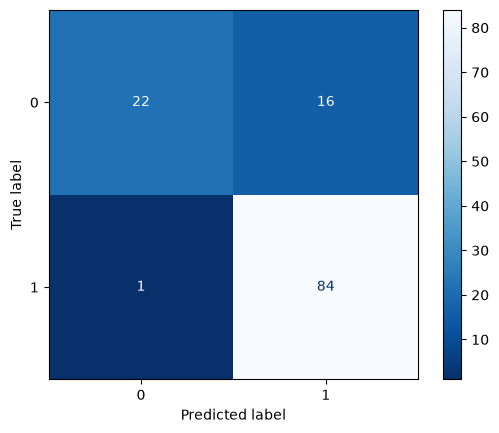

In [74]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred,cmap="Blues_r")
plt.show()

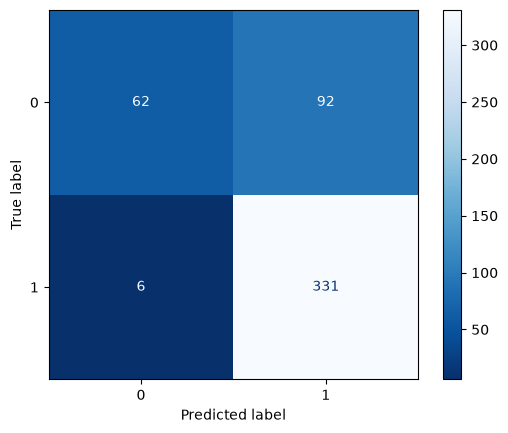

In [75]:
ConfusionMatrixDisplay.from_predictions(y_train, train_pred,cmap="Blues_r")
plt.show()

In [76]:
def evaluate(text, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)*100
    prec = precision_score(y_test, y_pred)*100
    rec = recall_score(y_test, y_pred)*100
    f1 = f1_score(y_test, y_pred)*100
    roc_auc = roc_auc_score(y_test, y_pred)*100
    print("*"*30)
    print(f"Evaluation Results for {text}:\n")
    print(f"Accuracy   : {acc:.2f}")
    print(f"Precision  : {prec:.2f}")
    print(f"Recall     : {rec:.2f}")
    print(f"F1 Score   : {f1:.2f}")
    print(f"ROC AUC    : {roc_auc:.2f}\n")
    print("*"*30)

In [77]:
evaluate("TRAIN",y_train,train_pred)
evaluate("TEST",y_test,test_pred)

******************************
Evaluation Results for TRAIN:

Accuracy   : 80.04
Precision  : 78.25
Recall     : 98.22
F1 Score   : 87.11
ROC AUC    : 69.24

******************************
******************************
Evaluation Results for TEST:

Accuracy   : 86.18
Precision  : 84.00
Recall     : 98.82
F1 Score   : 90.81
ROC AUC    : 78.36

******************************


## **HYPERPARAMETER TUNING**

In [78]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best Cross Validation Accuracy:
0.8004122861265719


c:\Users\UDAY SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [79]:
best_model = grid.best_estimator_

optimized_pred = best_model.predict(X_test)

evaluate("OPTIMIZED MODEL", y_test, optimized_pred)

******************************
Evaluation Results for OPTIMIZED MODEL:

Accuracy   : 86.18
Precision  : 84.00
Recall     : 98.82
F1 Score   : 90.81
ROC AUC    : 78.36

******************************


## **SAVE PKL**

In [80]:
joblib.dump(best_model, "loan_status_model.pkl")

print("Model saved successfully!")

Model saved successfully!
